In [1]:
import os

import pandas as pd

In [83]:
MODEL_NAME = "pocket2mol"
TARGET_IDX = 96
QED = "0.10"
SA = "1.0"

PROJECT_DIR = "/home/mseok/work/DL/DeepBioisostere/Resubmission_DeepBioisostere"
DOCKING_RESULTS_DIR = f"{PROJECT_DIR}/exps/fig5_new_case_study/20250520/docking/results/{MODEL_NAME}/{TARGET_IDX}/{QED}_{SA}/"

if os.path.exists(f"{DOCKING_RESULTS_DIR}/_summary.csv"):
    docking_scores_df = pd.read_csv(
        f"{DOCKING_RESULTS_DIR}/_summary.csv", low_memory=False
    )
else:
    docking_scores_df = pd.read_csv(
        f"{DOCKING_RESULTS_DIR}/summary.csv", low_memory=False
    )
    docking_scores_df.drop_duplicates(inplace=True)
    docking_scores_df.to_csv(f"{DOCKING_RESULTS_DIR}/_summary.csv", index=False)
docking_scores_df

,INPUT-MOL-IDX,INPUT-MOL-SMI,INPUT-MOL-DOCKED-SCORE,INPUT-ERROR,INPUT-MOL-GEN-SDF,INPUT-MOL-DOCKED-SDF,GEN-MOL-SMI,GEN-MOL-DOCKED-SCORE,GEN-ERROR,GEN-MOL-GEN-SDF,GEN-MOL-DOCKED-SDF,GEN-MOL-IDX
0,1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,-8.7,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,-8.1,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,0
1,1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,-8.7,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,-7.9,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,1
2,1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,-8.7,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,-7.9,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,2
3,1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,-8.7,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF,-8.4,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,3
4,1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,-8.7,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,-7.9,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,4
...,...,...,...,...,...,...,...,...,...,...,...,...
6395,64,CCCCCNC(=O)c1ccc(F)cn1,-5.4,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,COCC(C#N)NC(=O)c1ccc(F)cn1,-5.2,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,95
6396,64,CCCCCNC(=O)c1ccc(F)cn1,-5.4,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,O=C(NCC1COCCO1)c1ccc(F)cn1,-5.8,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,96
6397,64,CCCCCNC(=O)c1ccc(F)cn1,-5.4,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,C[C@H](CF)NC(=O)c1ccc(F)cn1,-5.0,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,97
6398,64,CCCCCNC(=O)c1ccc(F)cn1,-5.4,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,C[C@@H](O)[C@@H](C)NC(=O)c1ccc(F)cn1,-5.9,NaN,/scratch/mseok/147785/results/pocket2mol/96/0....,/scratch/mseok/147785/results/pocket2mol/96/0....,98


In [84]:
docking_score_diff = docking_scores_df.groupby("INPUT-MOL-IDX").apply(
    lambda x: (x["INPUT-MOL-DOCKED-SCORE"] - x["GEN-MOL-DOCKED-SCORE"]).min()
)
print(docking_score_diff)
print(docking_score_diff.mean(), docking_score_diff.max(), docking_score_diff.min())

INPUT-MOL-IDX
1    -1.4
2    -1.7
3    -0.1
4    -0.5
5    -0.8
     ... 
60   -1.9
61   -1.5
62   -0.7
63   -2.2
64   -0.8
Length: 64, dtype: float64
-1.165625 0.30000000000000027 -4.699999999999999


In [85]:
SHARE_DIR = "/home/share/DATA/wonho_SBDD_models_eval"
SBDD_PROP_CSV = f"{SHARE_DIR}/{MODEL_NAME}_eval/result.csv"
sbdd_prop_df = pd.read_csv(SBDD_PROP_CSV, low_memory=False)
target_sbdd_prop_df = sbdd_prop_df[sbdd_prop_df["test_idx"] == TARGET_IDX]
target_sbdd_prop_df

,error,test_idx,gen_idx,pro_fn,rec_fn,ref_fn,ref_score_fn,ref_min_fn,ref_dock_fn,gen_fn,...,ref_score_dock_aff_diff,SMILES,n_atom,QED,SA,gen_score_aff,gen_min_aff,gen_dock_aff,gen_score_min_aff_diff,gen_score_dock_aff_diff
9500,NaN,96,1,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_1.sdf,...,NaN,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,19.0,0.835850,0.77,-6.243,-7.856,-8.480,1.613,2.237
9501,NaN,96,2,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_2.sdf,...,NaN,O=C1c2c(O)cccc2N[C@H](O)[C@H]1O,14.0,0.455251,0.71,-5.687,-6.307,-6.867,0.620,1.180
9502,NaN,96,3,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_3.sdf,...,NaN,Cc1ccc(COc2ccnc3ccccc23)cc1,19.0,0.696174,0.93,-5.763,-6.960,-7.830,1.197,2.067
9503,NaN,96,4,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_4.sdf,...,NaN,O[C@@]12CC[C@@H]3CCN[C@@H]3[C@H]1Oc1ccc(F)cc1O2,19.0,0.744764,0.64,-7.477,-8.049,-8.251,0.572,0.774
9504,NaN,96,5,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_5.sdf,...,NaN,CCC[C@H]1CCC(=O)[C@H]2[C@H](O)[C@@]3(CCOC3)OCN12,19.0,0.799288,0.55,-4.291,-6.498,-6.993,2.207,2.702
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9595,NaN,96,96,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_96.sdf,...,NaN,O=C(O)[C@H]1CO[C@@H]2[C@@H](O)[C@@H](O)[C@@H](...,18.0,0.354145,0.61,-3.913,-5.641,-6.833,1.728,2.920
9596,NaN,96,97,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_97.sdf,...,NaN,O=C(O)c1ccc(F)cc1,10.0,0.641686,0.98,-3.676,-4.029,-2.796,0.353,-0.880
9597,NaN,96,98,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_98.sdf,...,NaN,O[C@@H]1Cc2ccccc2CN1C1=NC=C(F)C1,17.0,0.742035,0.69,-5.844,-7.069,-7.408,1.225,1.564
9598,NaN,96,99,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_99.sdf,...,NaN,OC[C@@]12CCCC[C@@H]1N[C@@H](c1ccccc1O)O2,18.0,0.746071,0.67,-6.320,-7.378,-8.164,1.058,1.844


In [86]:
bioiso_prop_csv = f"{PROJECT_DIR}/exps/fig5_new_case_study/20250520/gen/{MODEL_NAME}/{TARGET_IDX}/{QED}_{SA}.csv"
bioiso_prop_df = pd.read_csv(bioiso_prop_csv, low_memory=False)
bioiso_prop_df

,INPUT-MOL-IDX,INPUT-MOL-SMI,GEN-MOL-SMI,LEAVING-FRAG-SMI,INSERTING-FRAG-SMI,PREDICTED-PROB,LOGP,MW,QED,SA
0,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCCC1OC,0.000105,1.51480,293.106336,0.897819,3.692440
1,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCCCC1C#N,0.000105,1.82458,302.106671,0.858575,3.624886
2,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCSC1C,0.000105,1.84130,295.067843,0.858719,3.872919
3,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF,[5*]N1CCCC1,[5*]N1CCOC1CF,0.000105,1.07430,297.081264,0.887052,3.984397
4,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCCC[C@H]1C#N,0.000105,1.82458,302.106671,0.858575,3.624886
...,...,...,...,...,...,...,...,...,...,...
6395,64.0,CCCCCNC(=O)c1ccc(F)cn1,COCC(C#N)NC(=O)c1ccc(F)cn1,[4*]CCCCC,[4*]C(C#N)COC,0.000114,0.48908,223.075705,0.805531,2.977211
6396,64.0,CCCCCNC(=O)c1ccc(F)cn1,O=C(NCC1COCCO1)c1ccc(F)cn1,[4*]CCCCC,[4*]CC1COCCO1,0.000114,0.36590,240.091020,0.828647,2.764595
6397,64.0,CCCCCNC(=O)c1ccc(F)cn1,C[C@H](CF)NC(=O)c1ccc(F)cn1,[4*]CCCCC,[4*][C@H](C)CF,0.000114,1.30850,200.076119,0.798788,2.815511
6398,64.0,CCCCCNC(=O)c1ccc(F)cn1,C[C@@H](O)[C@@H](C)NC(=O)c1ccc(F)cn1,[4*]CCCCC,[4*][C@H](C)[C@@H](C)O,0.000114,0.71980,212.096106,0.775627,2.957858


In [87]:
# entries that target_sbdd_prop_df["SMILES"] == bioiso_prop_df["INPUT-MOL-SMI"]
target_sbdd_prop_df_filtered = target_sbdd_prop_df[
    target_sbdd_prop_df["SMILES"].isin(bioiso_prop_df["INPUT-MOL-SMI"])
].copy()

# copmute difference of QED and SA for the entries that target_sbdd_prop_df["SMILES"] == bioiso_prop_df["INPUT-MOL-SMI"]
bioiso_prop_df = bioiso_prop_df[
    bioiso_prop_df["INPUT-MOL-SMI"].isin(target_sbdd_prop_df["SMILES"])
]
merged_df = pd.merge(
    target_sbdd_prop_df_filtered,
    bioiso_prop_df,
    left_on="SMILES",
    right_on="INPUT-MOL-SMI",
    how="inner",
    suffixes=("_target", "_bioiso_gen"),
)
merged_df

,error,test_idx,gen_idx,pro_fn,rec_fn,ref_fn,ref_score_fn,ref_min_fn,ref_dock_fn,gen_fn,...,INPUT-MOL-IDX,INPUT-MOL-SMI,GEN-MOL-SMI,LEAVING-FRAG-SMI,INSERTING-FRAG-SMI,PREDICTED-PROB,LOGP,MW,QED_bioiso_gen,SA_bioiso_gen
0,NaN,96,1,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_1.sdf,...,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCCC1OC,0.000105,1.51480,293.106336,0.897819,3.692440
1,NaN,96,1,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_1.sdf,...,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCCCC1C#N,0.000105,1.82458,302.106671,0.858575,3.624886
2,NaN,96,1,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_1.sdf,...,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCSC1C,0.000105,1.84130,295.067843,0.858719,3.872919
3,NaN,96,1,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_1.sdf,...,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF,[5*]N1CCCC1,[5*]N1CCOC1CF,0.000105,1.07430,297.081264,0.887052,3.984397
4,NaN,96,1,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_1.sdf,...,1.0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,[5*]N1CCCC1,[5*]N1CCCC[C@H]1C#N,0.000105,1.82458,302.106671,0.858575,3.624886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6395,NaN,96,100,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_100.sdf,...,64.0,CCCCCNC(=O)c1ccc(F)cn1,COCC(C#N)NC(=O)c1ccc(F)cn1,[4*]CCCCC,[4*]C(C#N)COC,0.000114,0.48908,223.075705,0.805531,2.977211
6396,NaN,96,100,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_100.sdf,...,64.0,CCCCCNC(=O)c1ccc(F)cn1,O=C(NCC1COCCO1)c1ccc(F)cn1,[4*]CCCCC,[4*]CC1COCCO1,0.000114,0.36590,240.091020,0.828647,2.764595
6397,NaN,96,100,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_100.sdf,...,64.0,CCCCCNC(=O)c1ccc(F)cn1,C[C@H](CF)NC(=O)c1ccc(F)cn1,[4*]CCCCC,[4*][C@H](C)CF,0.000114,1.30850,200.076119,0.798788,2.815511
6398,NaN,96,100,gen/96/pro.pdb,gen/96/rec.pdb,gen/96/ref.sdf,NaN,NaN,NaN,gen/96/gen_100.sdf,...,64.0,CCCCCNC(=O)c1ccc(F)cn1,C[C@@H](O)[C@@H](C)NC(=O)c1ccc(F)cn1,[4*]CCCCC,[4*][C@H](C)[C@@H](C)O,0.000114,0.71980,212.096106,0.775627,2.957858


In [88]:
merged_df["QED_diff"] = merged_df["QED_target"] - merged_df["QED_bioiso_gen"]
merged_df["SA_diff"] = merged_df["SA_target"] - merged_df["SA_bioiso_gen"]

In [89]:
_xx = merged_df.groupby("gen_idx").mean(["QED_diff", "SA_diff"])
_xx["QED_diff"].mean(), _xx["SA_diff"].mean()

(-0.04495530099689662, -3.2699971165675485)

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. target_sbdd_prop_df["SMILES"]가 bioiso_prop_df["INPUT-MOL-SMI"]에 있는 항목만 필터링
target_sbdd_prop_df_filtered = target_sbdd_prop_df[
    target_sbdd_prop_df["SMILES"].isin(bioiso_prop_df["INPUT-MOL-SMI"])
].copy()
print(
    f"target_sbdd_prop_df_filtered: {target_sbdd_prop_df_filtered.shape[0]} rows"
    f" / {target_sbdd_prop_df.shape[0]} rows"
)

# 2. QED 및 SA 값의 차이 계산을 위한 데이터 준비
# 2a. 원본 분자(INPUT-MOL)의 속성 준비 (필터링된 target_sbdd_prop_df 사용)
df_original_props = target_sbdd_prop_df_filtered.rename(
    columns={"SMILES": "INPUT-MOL-SMI", "QED": "QED_original", "SA": "SA_original"}
)
# 중복 INPUT-MOL-SMI가 있다면 대표값만 사용 (예: 첫 번째)
df_original_props = df_original_props.drop_duplicates(subset=["INPUT-MOL-SMI"])
# 필요한 컬럼만 선택
df_original_props = df_original_props[["INPUT-MOL-SMI", "QED_original", "SA_original"]]


def compute_original_sa(sa):
    new_sa = -(9 * sa - 10)
    return new_sa


df_original_props["SA_original"] = df_original_props["SA_original"].apply(
    compute_original_sa
)
print(
    f"df_original_props: {df_original_props.shape[0]} rows / "
    f"{target_sbdd_prop_df_filtered.shape[0]} rows"
)

# 2b. 생성된 분자(GEN-MOL)의 속성 준비 (bioiso_prop_df 사용)
df_generated_props = bioiso_prop_df.rename(columns={"QED": "QED_new", "SA": "SA_new"})
# 필요한 컬럼만 선택
df_generated_props = df_generated_props[
    ["INPUT-MOL-SMI", "GEN-MOL-SMI", "QED_new", "SA_new"]
]
print(
    f"df_generated_props: {df_generated_props.shape[0]} rows / "
    f"{bioiso_prop_df.shape[0]} rows"
)

# 2c. 도킹 점수 준비 (docking_scores_df 사용)
df_scores = docking_scores_df.rename(
    columns={
        "INPUT-MOL-DOCKED-SCORE": "Score_original",
        "GEN-MOL-DOCKED-SCORE": "Score_new",
    }
)
# 필요한 컬럼만 선택
df_scores = df_scores[["INPUT-MOL-SMI", "GEN-MOL-SMI", "Score_original", "Score_new"]]
print(f"df_scores: {df_scores.shape[0]} rows / {docking_scores_df.shape[0]} rows")

# 3. 데이터 병합

# 3a. 원본 분자 속성과 생성된 분자 속성 병합
# 각 INPUT-MOL-SMI에 대해 여러 GEN-MOL-SMI가 매칭될 수 있음
merged_df_props = pd.merge(
    df_original_props,
    df_generated_props,
    on="INPUT-MOL-SMI",
    how="inner",  # bioiso_prop_df에 나타난 INPUT-MOL-SMI만 고려
)

# 3b. 위 결과에 도킹 점수 병합
# (INPUT-MOL-SMI, GEN-MOL-SMI) 쌍을 기준으로 정확히 매칭
final_df = pd.merge(
    merged_df_props,
    df_scores,
    on=["INPUT-MOL-SMI", "GEN-MOL-SMI"],
    how="inner",  # 모든 정보(원본속성, 생성물속성, 양쪽 점수)가 있는 경우만 유지
)
final_df

target_sbdd_prop_df_filtered: 64 rows / 100 rows
df_original_props: 64 rows / 64 rows
df_generated_props: 6400 rows / 6400 rows
df_scores: 6400 rows / 6400 rows


,INPUT-MOL-SMI,QED_original,SA_original,GEN-MOL-SMI,QED_new,SA_new,Score_original,Score_new
0,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,0.835850,3.07,COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,0.897819,3.692440,-8.7,-8.1
1,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,0.835850,3.07,N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,0.858575,3.624886,-8.7,-7.9
2,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,0.835850,3.07,CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,0.858719,3.872919,-8.7,-7.9
3,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,0.835850,3.07,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF,0.887052,3.984397,-8.7,-8.4
4,O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1,0.835850,3.07,N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O,0.858575,3.624886,-8.7,-7.9
...,...,...,...,...,...,...,...,...
6395,CCCCCNC(=O)c1ccc(F)cn1,0.756395,1.81,COCC(C#N)NC(=O)c1ccc(F)cn1,0.805531,2.977211,-5.4,-5.2
6396,CCCCCNC(=O)c1ccc(F)cn1,0.756395,1.81,O=C(NCC1COCCO1)c1ccc(F)cn1,0.828647,2.764595,-5.4,-5.8
6397,CCCCCNC(=O)c1ccc(F)cn1,0.756395,1.81,C[C@H](CF)NC(=O)c1ccc(F)cn1,0.798788,2.815511,-5.4,-5.0
6398,CCCCCNC(=O)c1ccc(F)cn1,0.756395,1.81,C[C@@H](O)[C@@H](C)NC(=O)c1ccc(F)cn1,0.775627,2.957858,-5.4,-5.9


In [91]:
docking_score_diff = final_df["Score_new"] - final_df["Score_original"]
print(docking_score_diff.mean(), docking_score_diff.max(), docking_score_diff.min())

0.01564551422319474 4.699999999999999 -3.9000000000000004



--- 최종 병합 및 계산된 DataFrame 샘플 ---
                          INPUT-MOL-SMI                                    GEN-MOL-SMI  Delta_QED  Delta_SA  Delta_Score
0  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1         COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.061970  0.622440          0.6
1  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1       N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022725  0.554886          0.8
2  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1          CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022869  0.802919          0.8
3  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1         O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF   0.051202  0.914397          0.3
4  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1  N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022725  0.554886          0.8


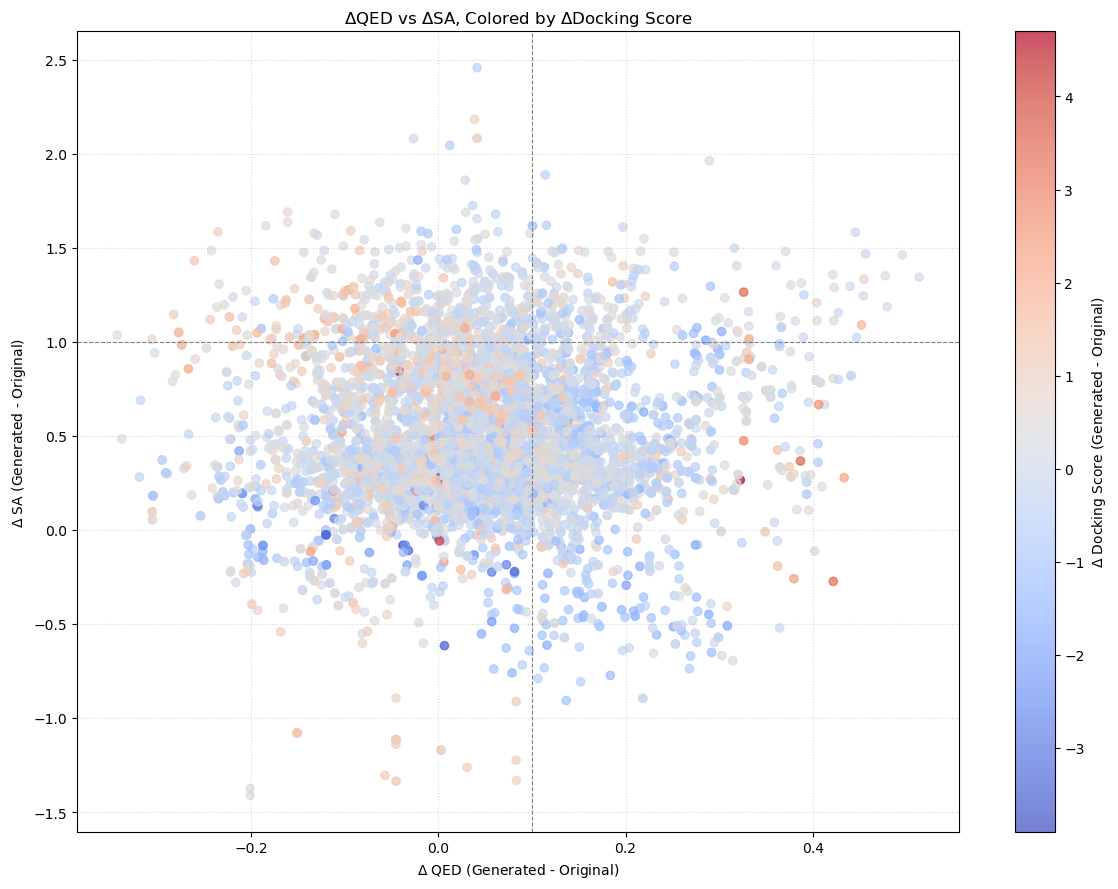

In [ ]:
# 4. 차이(Delta) 계산
final_df["Delta_QED"] = final_df["QED_new"] - final_df["QED_original"]
final_df["Delta_SA"] = final_df["SA_new"] - final_df["SA_original"]
final_df["Delta_Score"] = final_df["Score_new"] - final_df["Score_original"]

# 5. Scatter Plot 생성
print("\n--- 최종 병합 및 계산된 DataFrame 샘플 ---")
print(
    final_df[["INPUT-MOL-SMI", "GEN-MOL-SMI", "Delta_QED", "Delta_SA", "Delta_Score"]]
    .head()
    .to_string()
)

plt.figure(figsize=(12, 9))

# 점수 차이의 최소/최대값을 기준으로 컬러맵 범위 설정 (데이터에 따라 조정)
delta_scores = final_df["Delta_Score"].dropna()
vmin = delta_scores.min()
vmax = delta_scores.max()
# 0을 기준으로 하는 컬러맵을 사용하고 싶다면 TwoSlopeNorm 사용 가능

scatter = plt.scatter(
    final_df["Delta_QED"],
    final_df["Delta_SA"],
    c=final_df["Delta_Score"],
    cmap="coolwarm",
    alpha=0.7,
)

plt.colorbar(scatter, label="$\Delta$ Docking Score (Generated - Original)")
plt.xlabel("$\Delta$ QED (Generated - Original)")
plt.ylabel("$\Delta$ SA (Generated - Original)")
plt.title("$\Delta$QED vs $\Delta$SA, Colored by $\Delta$Docking Score")
plt.axhline(float(SA), color="grey", lw=0.8, linestyle="--")
plt.axvline(float(QED), color="grey", lw=0.8, linestyle="--")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


--- 최종 병합 및 계산된 DataFrame 샘플 (Hexbin 플롯용) ---
                          INPUT-MOL-SMI                                    GEN-MOL-SMI  Delta_QED  Delta_SA  Delta_Score
0  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1         COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.061970  0.622440          0.6
1  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1       N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022725  0.554886          0.8
2  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1          CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022869  0.802919          0.8
3  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1         O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF   0.051202  0.914397          0.3
4  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1  N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022725  0.554886          0.8


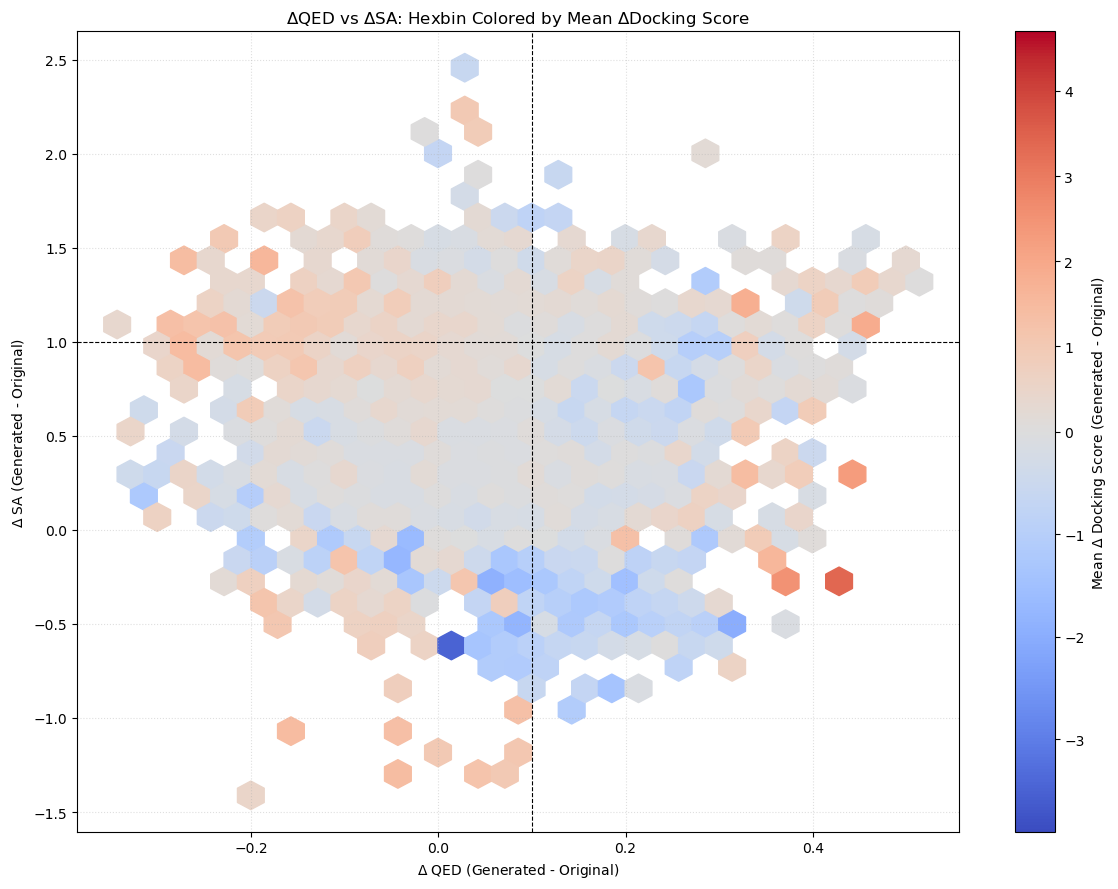

In [ ]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

final_df["Delta_QED"] = final_df["QED_new"] - final_df["QED_original"]
final_df["Delta_SA"] = final_df["SA_new"] - final_df["SA_original"]
final_df["Delta_Score"] = final_df["Score_new"] - final_df["Score_original"]

# 5. Hexbin 플롯 생성 (Delta_Score 값을 밀도처럼 표현)
if not final_df.empty and all(
    col in final_df.columns for col in ["Delta_QED", "Delta_SA", "Delta_Score"]
):
    print("\n--- 최종 병합 및 계산된 DataFrame 샘플 (Hexbin 플롯용) ---")
    print(
        final_df[
            ["INPUT-MOL-SMI", "GEN-MOL-SMI", "Delta_QED", "Delta_SA", "Delta_Score"]
        ]
        .head()
        .to_string()
    )

    plot_data = final_df[["Delta_QED", "Delta_SA", "Delta_Score"]].dropna()

    if not plot_data.empty:
        plt.figure(figsize=(12, 9))

        delta_scores_values = plot_data["Delta_Score"]
        vmin_score = delta_scores_values.min()
        vmax_score = delta_scores_values.max()

        norm_for_hexbin = None
        # Delta_Score가 0을 중심으로 양/음의 변화를 보인다면 TwoSlopeNorm이 유용
        if vmin_score < 0 < vmax_score:
            norm_for_hexbin = colors.TwoSlopeNorm(
                vmin=vmin_score, vcenter=0, vmax=vmax_score
            )
        elif delta_scores_values.nunique() > 1:  # 모든 값이 같지 않을 때만 Normalize
            norm_for_hexbin = colors.Normalize(vmin=vmin_score, vmax=vmax_score)

        # Hexbin 플롯: 각 육각형의 색상은 해당 육각형 내 데이터 포인트들의 C값(Delta_Score)의 평균으로 결정됨
        hb = plt.hexbin(
            x=plot_data["Delta_QED"],
            y=plot_data["Delta_SA"],
            C=plot_data["Delta_Score"],  # 각 점의 Z값 (이것의 평균이 색상으로 표현됨)
            reduce_C_function=np.mean,  # 각 육각형(bin) 내의 C값들을 평균냄
            gridsize=30,  # 육각형 그리드의 크기 (조절 가능)
            cmap="coolwarm",  # Delta_Score 표현에 적합한 발산형 컬러맵
            norm=norm_for_hexbin,  # 색상 정규화 적용 (0을 중심으로)
            mincnt=1,  # 최소 1개 이상의 점을 포함하는 육각형만 표시 (선택 사항)
            # extent = [xmin, xmax, ymin, ymax] # 축 범위 강제 지정 시 사용
        )

        cb = plt.colorbar(
            hb, label="Mean $\Delta$ Docking Score (Generated - Original)"
        )

        plt.xlabel("$\Delta$ QED (Generated - Original)")
        plt.ylabel("$\Delta$ SA (Generated - Original)")
        plt.title(
            "$\Delta$QED vs $\Delta$SA: Hexbin Colored by Mean $\Delta$Docking Score"
        )

        plt.axhline(float(SA), color="black", lw=0.8, linestyle="--")
        plt.axvline(float(QED), color="black", lw=0.8, linestyle="--")

        plt.grid(True, linestyle=":", alpha=0.4)
        plt.tight_layout()
        plt.show()
    else:
        print("\n플롯을 생성하기에 유효한 데이터(NaN 제외)가 충분하지 않습니다.")
else:
    print(
        "\nfinal_df가 비어있거나 필요한 Delta 컬럼이 없습니다. 데이터 병합 및 계산 단계를 확인해주세요."
    )


--- 최종 병합 및 계산된 DataFrame 샘플 (KDE 플롯용) ---
                          INPUT-MOL-SMI                                    GEN-MOL-SMI  Delta_QED  Delta_SA  Delta_Score
0  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1         COC1CCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.061970  0.622440          0.6
1  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1       N#CC1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022725  0.554886          0.8
2  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1          CC1SCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022869  0.802919          0.8
3  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1         O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCOC1CF   0.051202  0.914397          0.3
4  O=C(C1=Cc2cc(F)ccc2O[C@@H]1O)N1CCCC1  N#C[C@@H]1CCCCN1C(=O)C1=Cc2cc(F)ccc2O[C@@H]1O   0.022725  0.554886          0.8


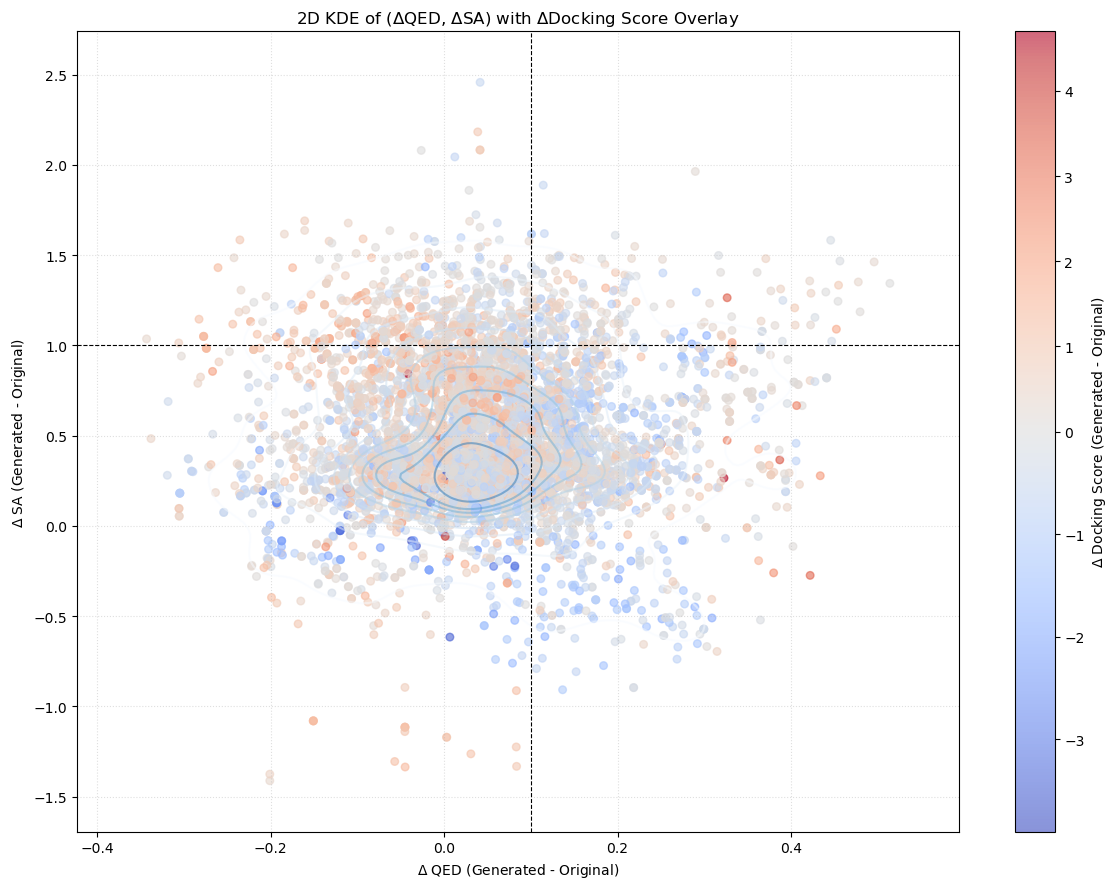

In [ ]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # Seaborn 추가

final_df["Delta_QED"] = final_df["QED_new"] - final_df["QED_original"]
final_df["Delta_SA"] = final_df["SA_new"] - final_df["SA_original"]
final_df["Delta_Score"] = final_df["Score_new"] - final_df["Score_original"]


# 4. 차이(Delta) 계산 (이전 코드와 동일)
if not final_df.empty:
    # QED_new, QED_original, SA_new, SA_original, Score_new, Score_original 컬럼이 final_df에 있다고 가정
    if all(
        col in final_df.columns
        for col in [
            "QED_new",
            "QED_original",
            "SA_new",
            "SA_original",
            "Score_new",
            "Score_original",
        ]
    ):
        final_df["Delta_QED"] = final_df["QED_new"] - final_df["QED_original"]
        final_df["Delta_SA"] = final_df["SA_new"] - final_df["SA_original"]
        final_df["Delta_Score"] = final_df["Score_new"] - final_df["Score_original"]

        # --- 사용자 요청 코드 종료 --- (Delta 계산까지)

        # 5. 2D KDE Plot과 Scatter Plot 중첩 생성
        print("\n--- 최종 병합 및 계산된 DataFrame 샘플 (KDE 플롯용) ---")
        print(
            final_df[
                ["INPUT-MOL-SMI", "GEN-MOL-SMI", "Delta_QED", "Delta_SA", "Delta_Score"]
            ]
            .head()
            .to_string()
        )

        # 유효한 데이터가 있는지 확인 (NaN이 아닌 데이터)
        plot_data = final_df[["Delta_QED", "Delta_SA", "Delta_Score"]].dropna()

        if not plot_data.empty:
            plt.figure(figsize=(12, 9))

            # 2D KDE 플롯 (밀도)
            sns.kdeplot(
                x=plot_data["Delta_QED"],
                y=plot_data["Delta_SA"],
                cmap="Blues",  # 밀도 표시에 사용할 컬러맵 (예: "Blues", "Greens", "viridis_r")
                # fill=True,  # 밀도 영역 채우기
                thresh=0.05,  # 밀도 수준 임계값 (이 값 이하의 밀도는 표시 안 함)
                alpha=0.5,  # KDE 플롯의 투명도
                levels=10,  # 등고선 개수 (fill=True 대신 사용 가능)
                # cbar=True,    # 밀도에 대한 컬러바 표시 (산점도 컬러바와 중복될 수 있어 주석 처리)
                # cbar_kws={'label': 'Density'}
            )

            # Scatter 플롯 (개별 데이터 포인트, Delta_Score로 색칠)
            delta_scores = plot_data["Delta_Score"]  # dropna된 데이터 사용
            vmin_score = delta_scores.min()
            vmax_score = delta_scores.max()

            norm_score = None
            # 점수 변화가 0을 중심으로 양/음수 모두 의미있게 분포하면 TwoSlopeNorm 사용
            if vmin_score < 0 < vmax_score:
                norm_score = colors.TwoSlopeNorm(
                    vmin=vmin_score, vcenter=0.0, vmax=vmax_score
                )
            elif delta_scores.nunique() > 1:  # 모든 값이 같지 않을 때만 Normalize
                norm_score = colors.Normalize(vmin=vmin_score, vmax=vmax_score)

            scatter_overlay = plt.scatter(
                plot_data["Delta_QED"],
                plot_data["Delta_SA"],
                c=delta_scores,
                cmap="coolwarm",  # Delta_Score 표시에 사용할 컬러맵 (발산형)
                alpha=0.6,  # 산점도 점의 투명도
                norm=norm_score,  # 정규화 적용 (0을 중심으로)
                s=30,  # 점 크기
                # edgecolor="k",  # 점 테두리 색상 (선택 사항)
                # linewidth=0.5,  # 점 테두리 두께 (선택 사항)
            )

            plt.colorbar(
                scatter_overlay, label="$\Delta$ Docking Score (Generated - Original)"
            )

            plt.xlabel("$\Delta$ QED (Generated - Original)")
            plt.ylabel("$\Delta$ SA (Generated - Original)")
            plt.title(
                "2D KDE of ($\Delta$QED, $\Delta$SA) with $\Delta$Docking Score Overlay"
            )

            # 0점선 (변화 없음을 나타내는 기준선)
            plt.axhline(float(SA), color="black", lw=0.8, linestyle="--")
            plt.axvline(float(QED), color="black", lw=0.8, linestyle="--")

            plt.grid(True, linestyle=":", alpha=0.4)
            plt.tight_layout()
            plt.show()
        else:
            print("\n플롯을 생성하기에 유효한 데이터(NaN 제외)가 충분하지 않습니다.")
    else:
        print("\nDelta 값을 계산하기 위한 필수 컬럼이 final_df에 없습니다.")
else:
    print("\n병합 결과 데이터가 없습니다. 입력 DataFrame 또는 키 컬럼을 확인해주세요.")